---
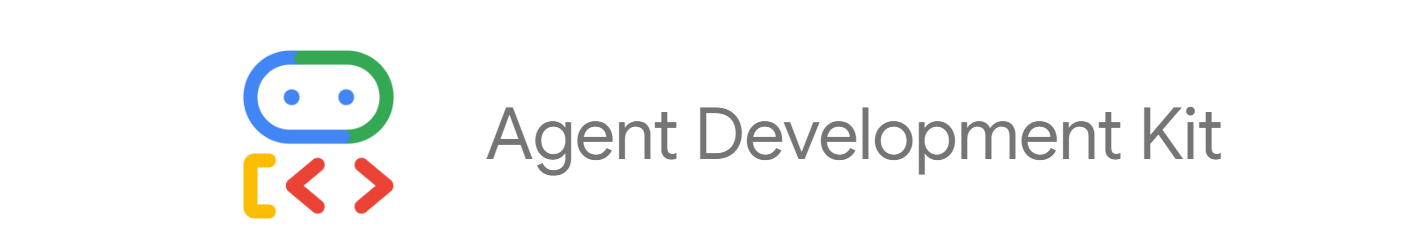

---

# Module 10: Callbacks: Observe, Customize, and Control Agent Behavior
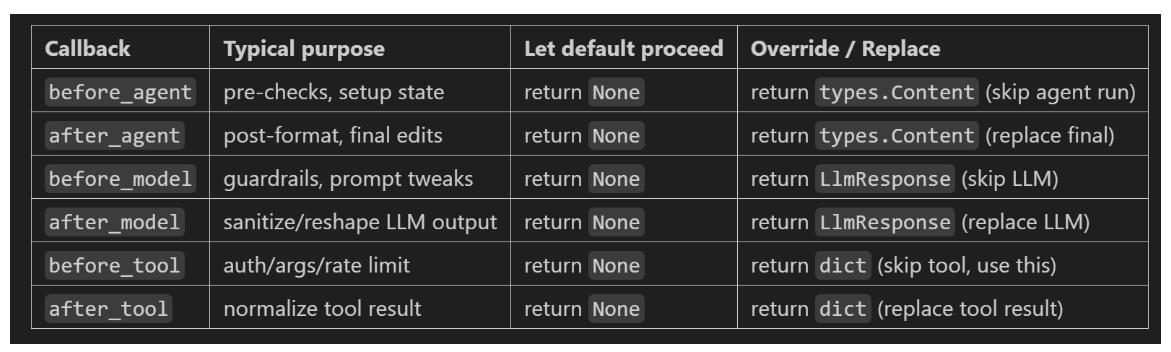 <br><br>

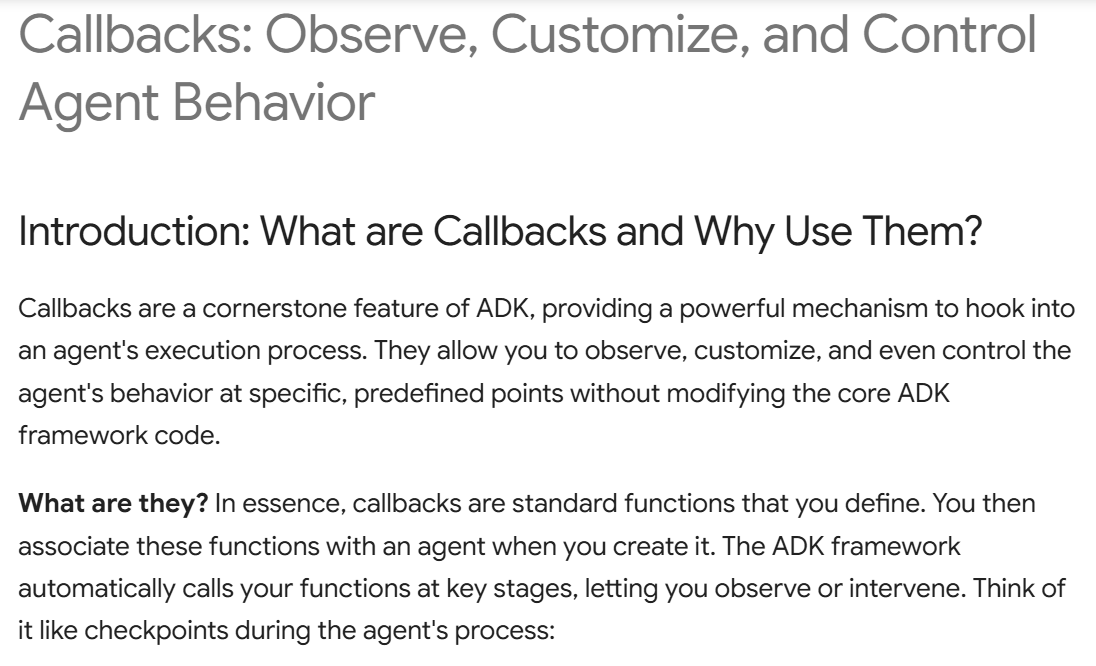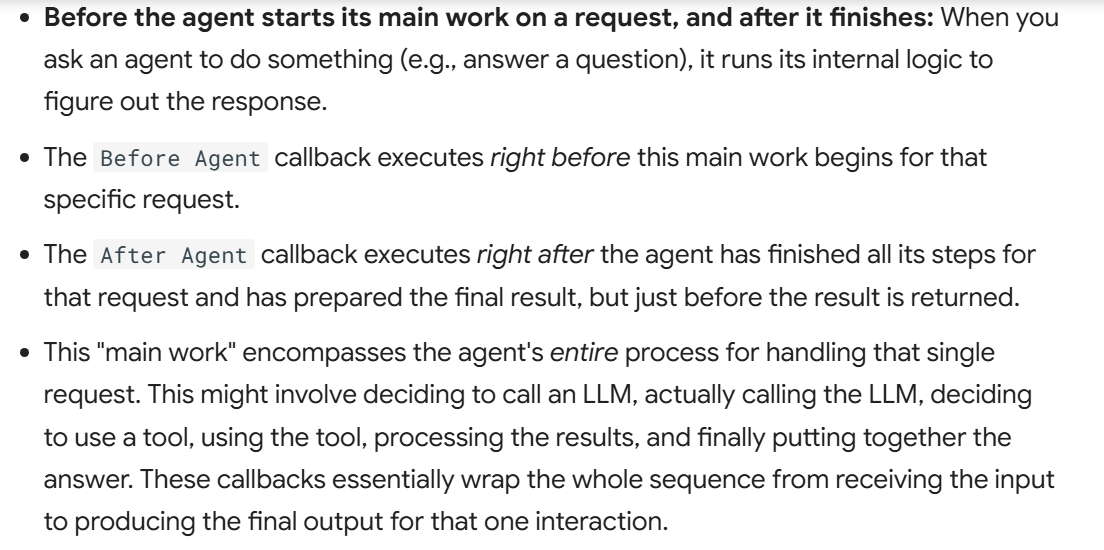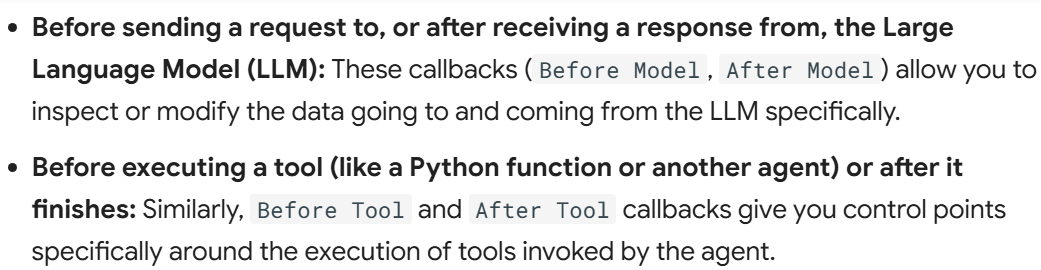 <br><br>

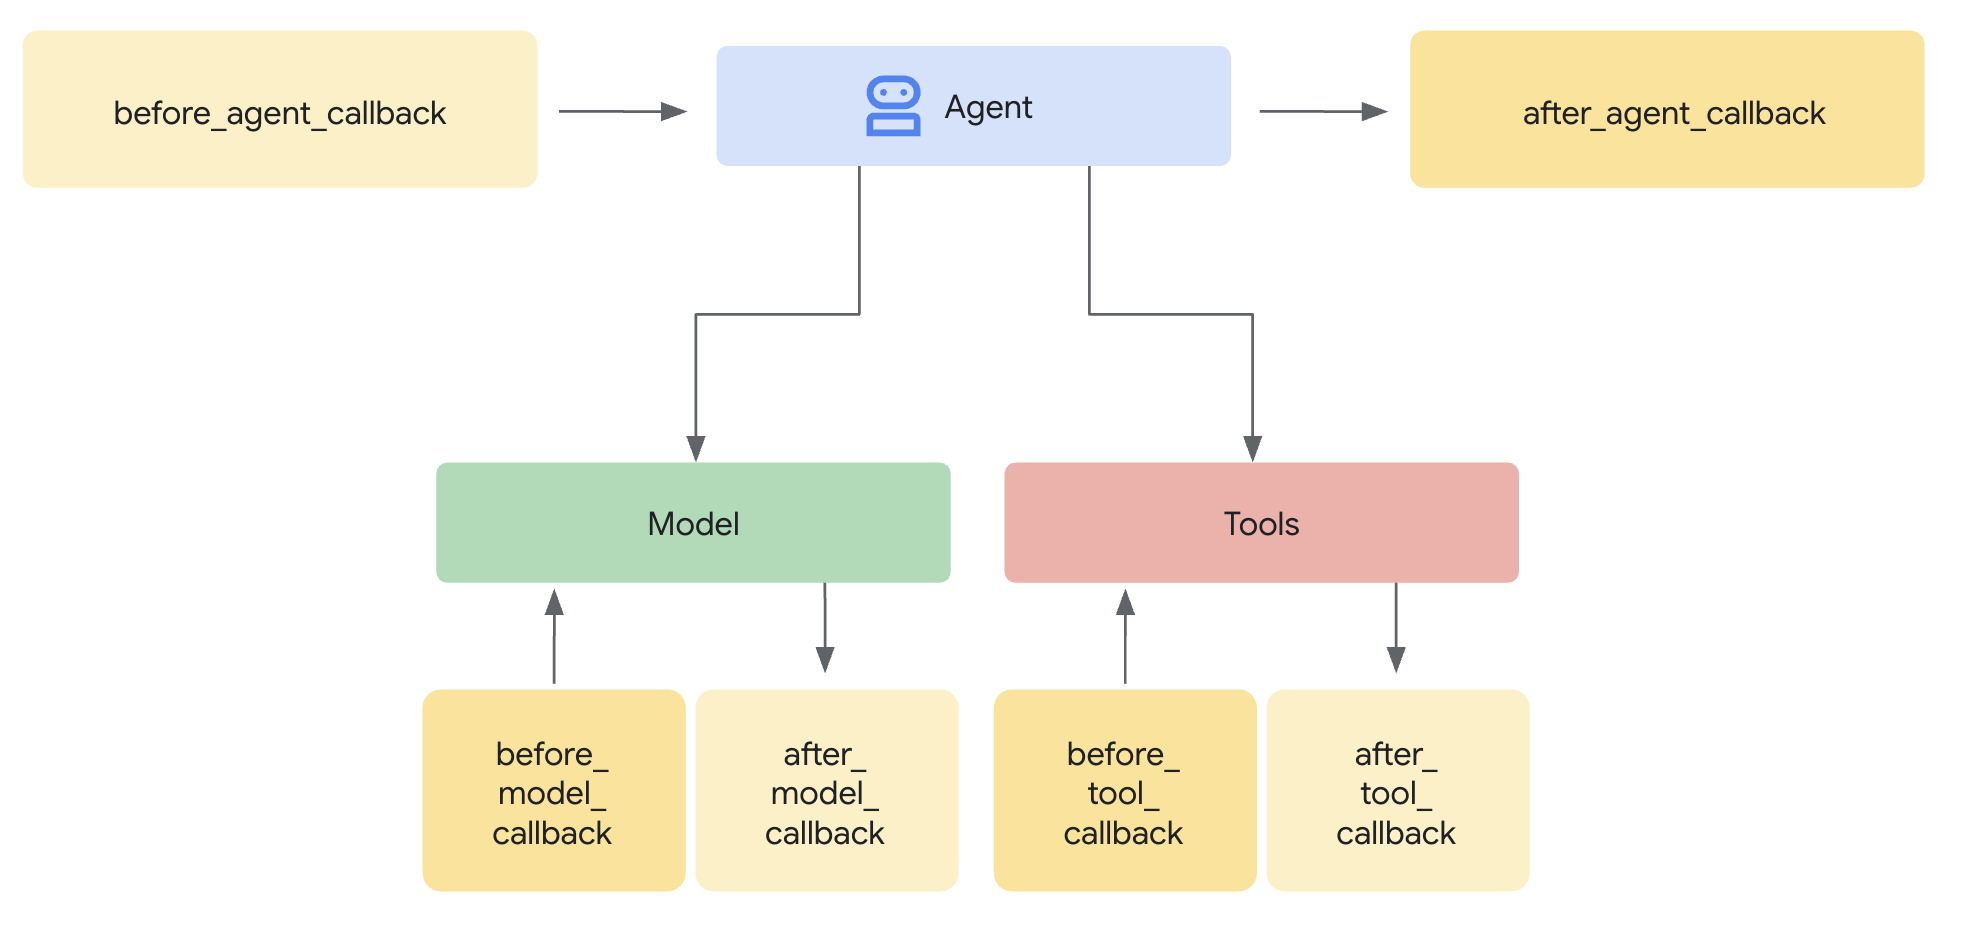 <br><br>

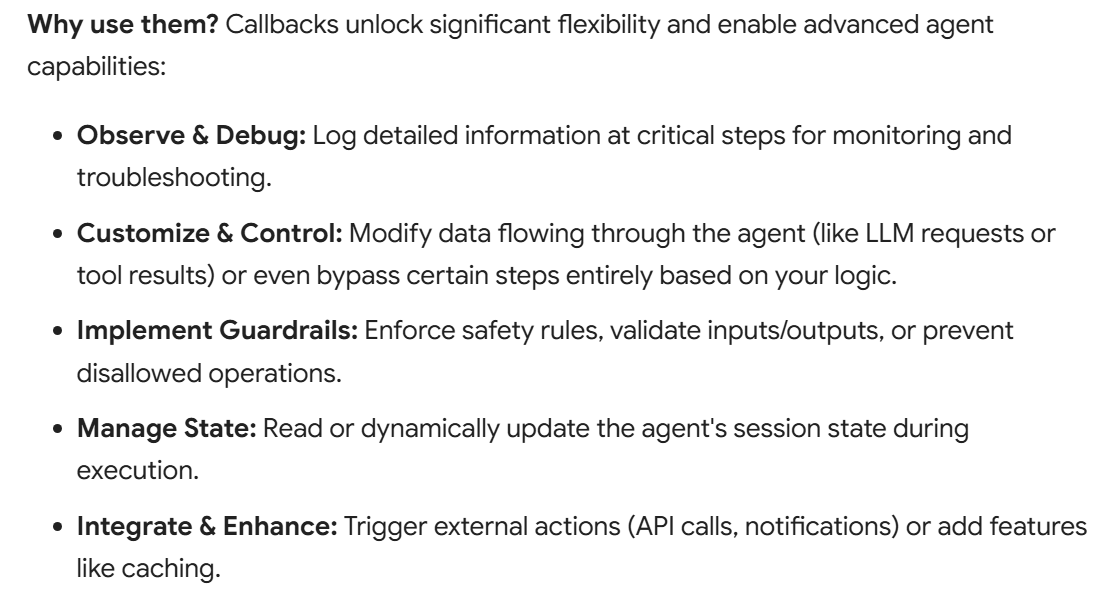 

> Tip <br> When implementing security guardrails and policies, use ADK Plugins for better modularity and flexibility than Callbacks. For more details, see [Callbacks and Plugins for Security Guardrails](https://google.github.io/adk-docs/safety/#callbacks-and-plugins-for-security-guardrails).

## `Where callbacks fire`
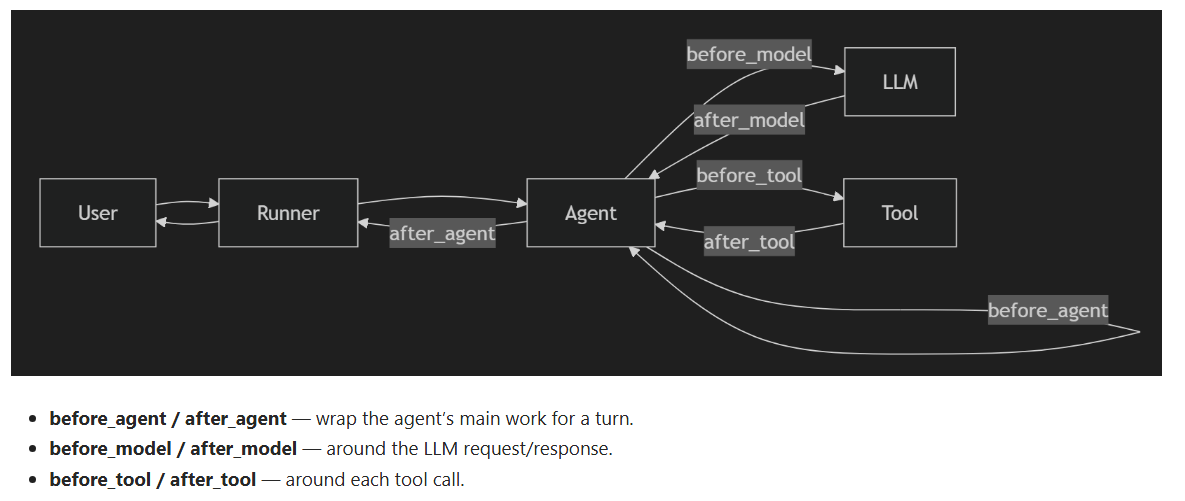

## `Code`
```Python
from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmResponse, LlmRequest
from typing import Optional

# --- Define your callback function ---
def my_before_model_logic(
    callback_context: CallbackContext, llm_request: LlmRequest
) -> Optional[LlmResponse]:
    print(f"Callback running before model call for agent: {callback_context.agent_name}")
    # ... your custom logic here ...
    return None # Allow the model call to proceed

# --- Register it during Agent creation ---
my_agent = LlmAgent(
    name="MyCallbackAgent",
    model="gemini-2.0-flash", # Or your desired model
    instruction="Be helpful.",
    # Other agent parameters...
    before_model_callback=my_before_model_logic # Pass the function here
)
```

# The Callback Mechanism: Interception and Control
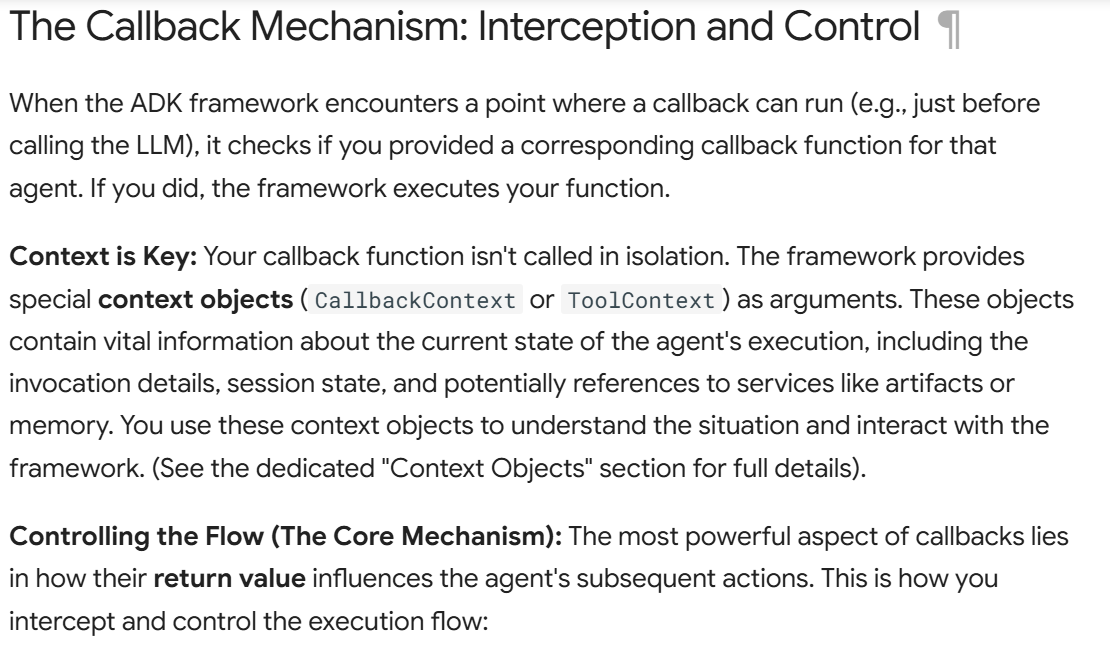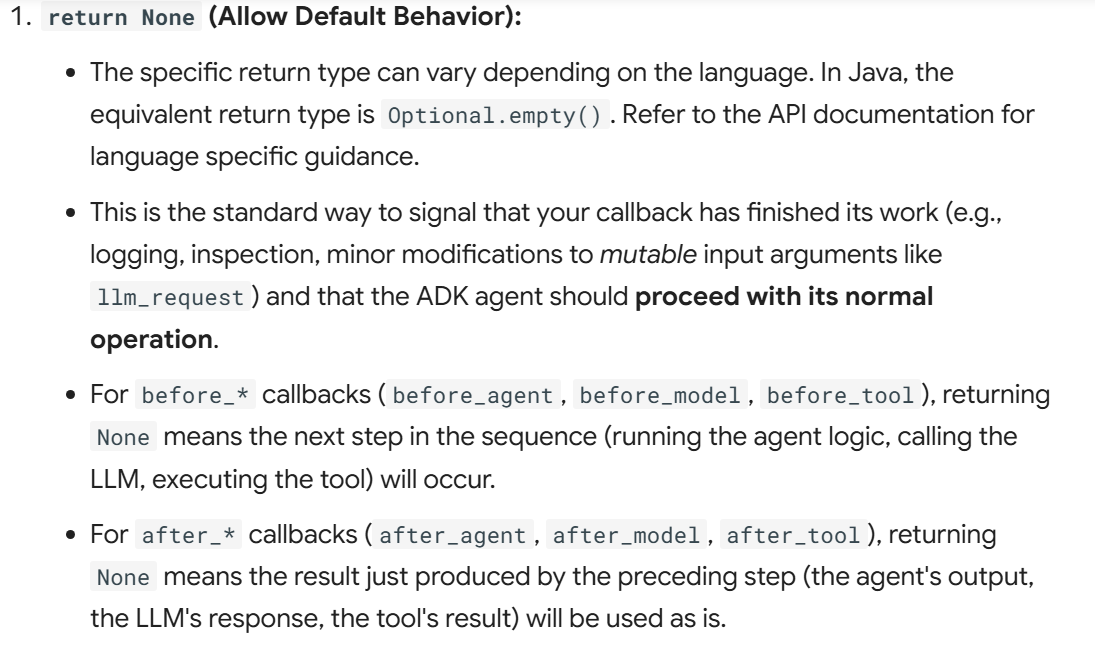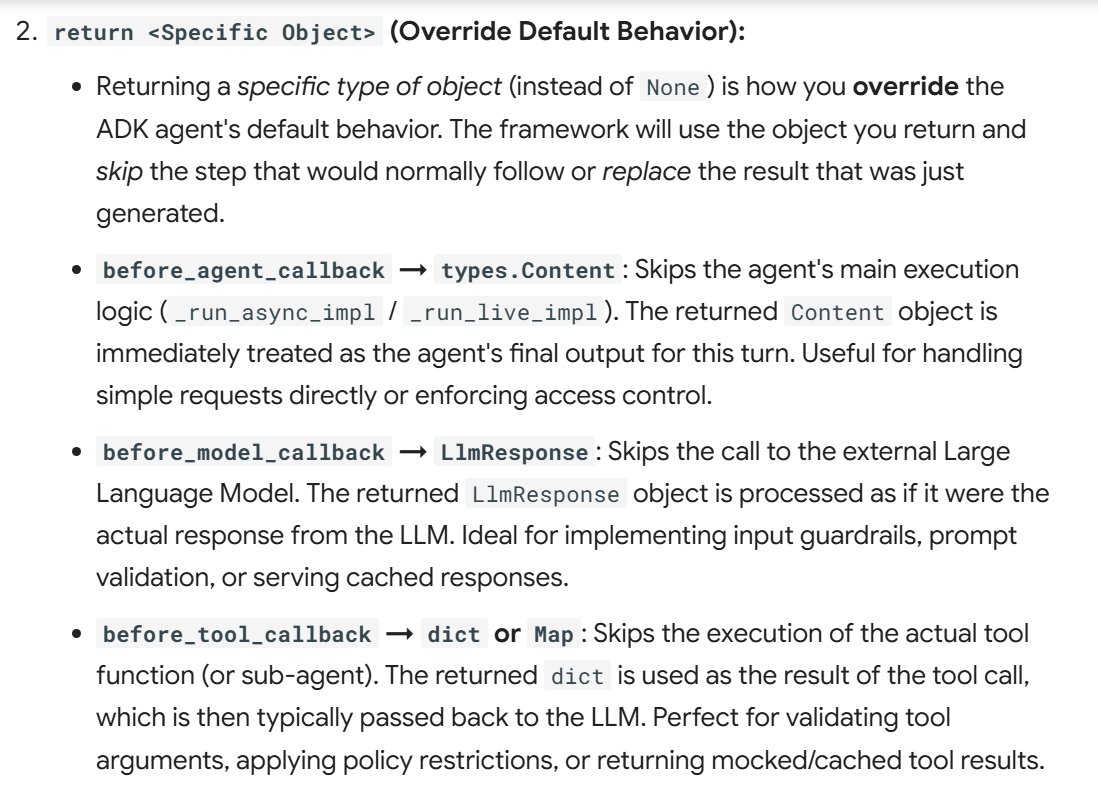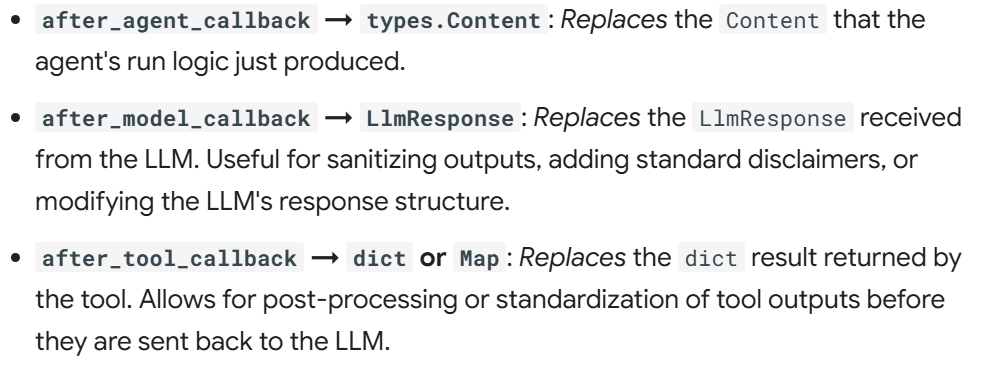

## `Conceptual Code Example (Guardrail):`
### This example demonstrates the common pattern for a guardrail using `before_model_callback`.
```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmResponse, LlmRequest
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService

GEMINI_2_FLASH="gemini-2.0-flash"

# --- Define the Callback Function ---
def simple_before_model_modifier(
    callback_context: CallbackContext, llm_request: LlmRequest
) -> Optional[LlmResponse]:
    """Inspects/modifies the LLM request or skips the call."""
    agent_name = callback_context.agent_name
    print(f"[Callback] Before model call for agent: {agent_name}")

    # Inspect the last user message in the request contents
    last_user_message = ""
    if llm_request.contents and llm_request.contents[-1].role == 'user':
         if llm_request.contents[-1].parts:
            last_user_message = llm_request.contents[-1].parts[0].text
    print(f"[Callback] Inspecting last user message: '{last_user_message}'")

    # --- Modification Example ---
    # Add a prefix to the system instruction
    original_instruction = llm_request.config.system_instruction or types.Content(role="system", parts=[])
    prefix = "[Modified by Callback] "
    # Ensure system_instruction is Content and parts list exists
    if not isinstance(original_instruction, types.Content):
         # Handle case where it might be a string (though config expects Content)
         original_instruction = types.Content(role="system", parts=[types.Part(text=str(original_instruction))])
    if not original_instruction.parts:
        original_instruction.parts.append(types.Part(text="")) # Add an empty part if none exist

    # Modify the text of the first part
    modified_text = prefix + (original_instruction.parts[0].text or "")
    original_instruction.parts[0].text = modified_text
    llm_request.config.system_instruction = original_instruction
    print(f"[Callback] Modified system instruction to: '{modified_text}'")

    # --- Skip Example ---
    # Check if the last user message contains "BLOCK"
    if "BLOCK" in last_user_message.upper():
        print("[Callback] 'BLOCK' keyword found. Skipping LLM call.")
        # Return an LlmResponse to skip the actual LLM call
        return LlmResponse(
            content=types.Content(
                role="model",
                parts=[types.Part(text="LLM call was blocked by before_model_callback.")],
            )
        )
    else:
        print("[Callback] Proceeding with LLM call.")
        # Return None to allow the (modified) request to go to the LLM
        return None


# Create LlmAgent and Assign Callback
my_llm_agent = LlmAgent(
        name="ModelCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are a helpful assistant.", # Base instruction
        description="An LLM agent demonstrating before_model_callback",
        before_model_callback=simple_before_model_modifier # Assign the function here
)

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner


# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("write a joke on BLOCK")
```

> By understanding this mechanism of returning `None` versus returning specific objects, you can precisely control the agent's execution path, making callbacks an essential tool for building sophisticated and reliable agents with `ADK`.

---

# Types of callbacks
The framework provides different types of callbacks that trigger at various stages of an agent's execution. Understanding when each callback fires and what context it receives is key to using them effectively.<br><br>

## Agent Lifecycle Callbacks
These callbacks are available on any agent that inherits from `BaseAgent` (including `LlmAgent`, `SequentialAgent`, `ParallelAgent`, `LoopAgent`, etc).

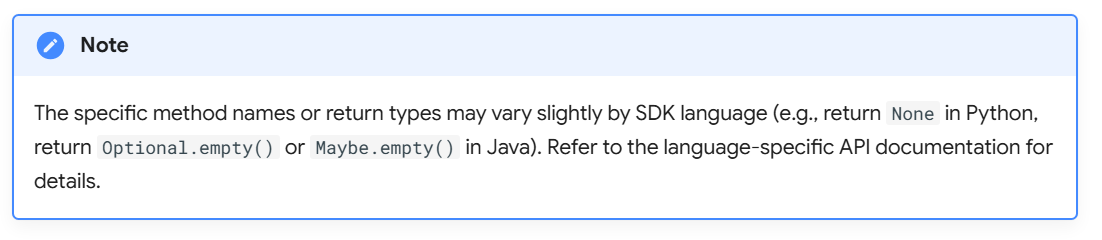

## `Before Agent Callback`
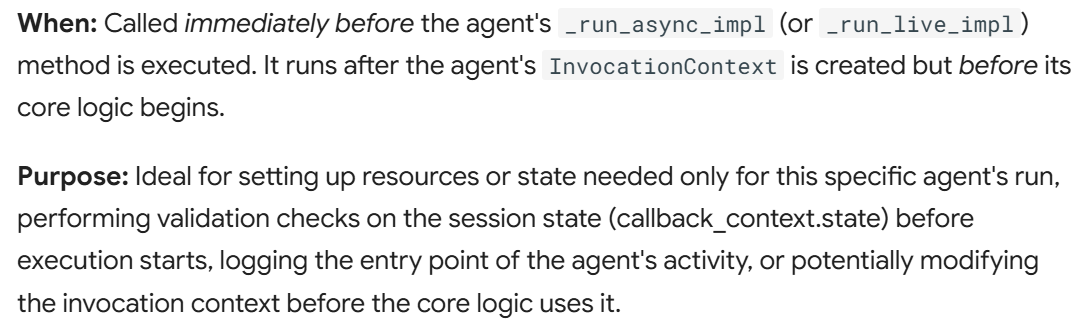

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# # --- Setup Instructions ---
# # 1. Install the ADK package:
# !pip install google-adk
# # Make sure to restart kernel if using colab/jupyter notebooks

# # 2. Set up your Gemini API Key:
# #    - Get a key from Google AI Studio: https://aistudio.google.com/app/apikey
# #    - Set it as an environment variable:
# import os
# os.environ["GOOGLE_API_KEY"] = "YOUR_API_KEY_HERE" # <--- REPLACE with your actual key
# # Or learn about other authentication methods (like Vertex AI):
# # https://google.github.io/adk-docs/agents/models/

# ADK Imports
from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.runners import InMemoryRunner # Use InMemoryRunner
from google.genai import types # For types.Content
from typing import Optional

# Define the model - Use the specific model name requested
GEMINI_2_FLASH="gemini-2.0-flash"

# --- 1. Define the Callback Function ---
def check_if_agent_should_run(callback_context: CallbackContext) -> Optional[types.Content]:
    """
    Logs entry and checks 'skip_llm_agent' in session state.
    If True, returns Content to skip the agent's execution.
    If False or not present, returns None to allow execution.
    """
    agent_name = callback_context.agent_name
    invocation_id = callback_context.invocation_id
    current_state = callback_context.state.to_dict()

    print(f"\n[Callback] Entering agent: {agent_name} (Inv: {invocation_id})")
    print(f"[Callback] Current State: {current_state}")

    # Check the condition in session state dictionary
    if current_state.get("skip_llm_agent", False):
        print(f"[Callback] State condition 'skip_llm_agent=True' met: Skipping agent {agent_name}.")
        # Return Content to skip the agent's run
        return types.Content(
            parts=[types.Part(text=f"Agent {agent_name} skipped by before_agent_callback due to state.")],
            role="model" # Assign model role to the overriding response
        )
    else:
        print(f"[Callback] State condition not met: Proceeding with agent {agent_name}.")
        # Return None to allow the LlmAgent's normal execution
        return None

# --- 2. Setup Agent with Callback ---
llm_agent_with_before_cb = LlmAgent(
    name="MyControlledAgent",
    model=GEMINI_2_FLASH,
    instruction="You are a concise assistant.",
    description="An LLM agent demonstrating stateful before_agent_callback",
    before_agent_callback=check_if_agent_should_run # Assign the callback
)

# --- 3. Setup Runner and Sessions using InMemoryRunner ---
async def main():
    app_name = "before_agent_demo"
    user_id = "test_user"
    session_id_run = "session_will_run"
    session_id_skip = "session_will_skip"

    # Use InMemoryRunner - it includes InMemorySessionService
    runner = InMemoryRunner(agent=llm_agent_with_before_cb, app_name=app_name)
    # Get the bundled session service to create sessions
    session_service = runner.session_service

    # Create session 1: Agent will run (default empty state)
    session_service.create_session(
        app_name=app_name,
        user_id=user_id,
        session_id=session_id_run
        # No initial state means 'skip_llm_agent' will be False in the callback check
    )

    # Create session 2: Agent will be skipped (state has skip_llm_agent=True)
    session_service.create_session(
        app_name=app_name,
        user_id=user_id,
        session_id=session_id_skip,
        state={"skip_llm_agent": True} # Set the state flag here
    )

    # --- Scenario 1: Run where callback allows agent execution ---
    print("\n" + "="*20 + f" SCENARIO 1: Running Agent on Session '{session_id_run}' (Should Proceed) " + "="*20)
    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id_run,
        new_message=types.Content(role="user", parts=[types.Part(text="Hello, please respond.")])
    ):
        # Print final output (either from LLM or callback override)
        if event.is_final_response() and event.content:
            print(f"Final Output: [{event.author}] {event.content.parts[0].text.strip()}")
        elif event.is_error():
             print(f"Error Event: {event.error_details}")

    # --- Scenario 2: Run where callback intercepts and skips agent ---
    print("\n" + "="*20 + f" SCENARIO 2: Running Agent on Session '{session_id_skip}' (Should Skip) " + "="*20)
    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id_skip,
        new_message=types.Content(role="user", parts=[types.Part(text="This message won't reach the LLM.")])
    ):
         # Print final output (either from LLM or callback override)
         if event.is_final_response() and event.content:
            print(f"Final Output: [{event.author}] {event.content.parts[0].text.strip()}")
         elif event.is_error():
             print(f"Error Event: {event.error_details}")

# --- 4. Execute ---
# In a Python script:
# import asyncio
# if __name__ == "__main__":
#     # Make sure GOOGLE_API_KEY environment variable is set if not using Vertex AI auth
#     # Or ensure Application Default Credentials (ADC) are configured for Vertex AI
#     asyncio.run(main())

# In a Jupyter Notebook or similar environment:
await main()
```
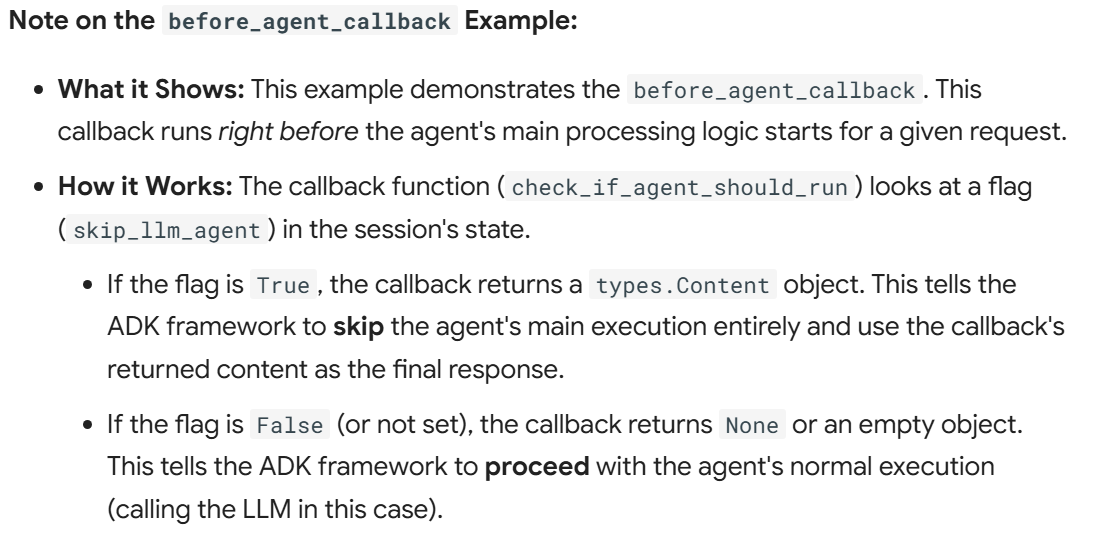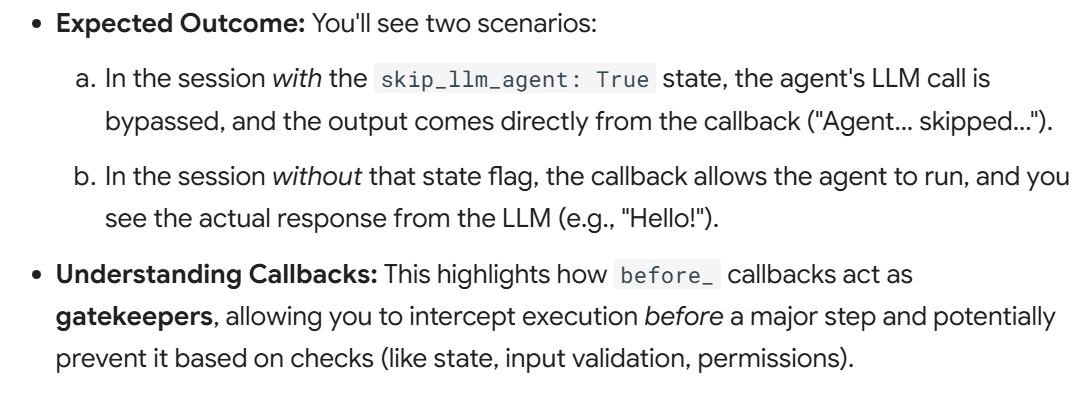 <br><br>

## `After Agent Callback`
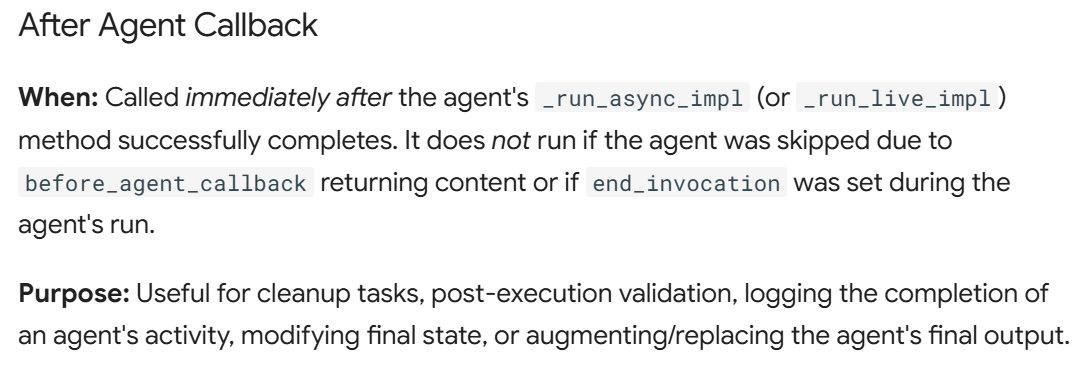 <br>

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# # --- Setup Instructions ---
# # 1. Install the ADK package:
# !pip install google-adk
# # Make sure to restart kernel if using colab/jupyter notebooks

# # 2. Set up your Gemini API Key:
# #    - Get a key from Google AI Studio: https://aistudio.google.com/app/apikey
# #    - Set it as an environment variable:
# import os
# os.environ["GOOGLE_API_KEY"] = "YOUR_API_KEY_HERE" # <--- REPLACE with your actual key
# # Or learn about other authentication methods (like Vertex AI):
# # https://google.github.io/adk-docs/agents/models/


# ADK Imports
from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.runners import InMemoryRunner # Use InMemoryRunner
from google.genai import types # For types.Content
from typing import Optional

# Define the model - Use the specific model name requested
GEMINI_2_FLASH="gemini-2.0-flash"

# --- 1. Define the Callback Function ---
def modify_output_after_agent(callback_context: CallbackContext) -> Optional[types.Content]:
    """
    Logs exit from an agent and checks 'add_concluding_note' in session state.
    If True, returns new Content to *replace* the agent's original output.
    If False or not present, returns None, allowing the agent's original output to be used.
    """
    agent_name = callback_context.agent_name
    invocation_id = callback_context.invocation_id
    current_state = callback_context.state.to_dict()

    print(f"\n[Callback] Exiting agent: {agent_name} (Inv: {invocation_id})")
    print(f"[Callback] Current State: {current_state}")

    # Example: Check state to decide whether to modify the final output
    if current_state.get("add_concluding_note", False):
        print(f"[Callback] State condition 'add_concluding_note=True' met: Replacing agent {agent_name}'s output.")
        # Return Content to *replace* the agent's own output
        return types.Content(
            parts=[types.Part(text=f"Concluding note added by after_agent_callback, replacing original output.")],
            role="model" # Assign model role to the overriding response
        )
    else:
        print(f"[Callback] State condition not met: Using agent {agent_name}'s original output.")
        # Return None - the agent's output produced just before this callback will be used.
        return None

# --- 2. Setup Agent with Callback ---
llm_agent_with_after_cb = LlmAgent(
    name="MySimpleAgentWithAfter",
    model=GEMINI_2_FLASH,
    instruction="You are a simple agent. Just say 'Processing complete!'",
    description="An LLM agent demonstrating after_agent_callback for output modification",
    after_agent_callback=modify_output_after_agent # Assign the callback here
)

# --- 3. Setup Runner and Sessions using InMemoryRunner ---
async def main():
    app_name = "after_agent_demo"
    user_id = "test_user_after"
    session_id_normal = "session_run_normally"
    session_id_modify = "session_modify_output"

    # Use InMemoryRunner - it includes InMemorySessionService
    runner = InMemoryRunner(agent=llm_agent_with_after_cb, app_name=app_name)
    # Get the bundled session service to create sessions
    session_service = runner.session_service

    # Create session 1: Agent output will be used as is (default empty state)
    session_service.create_session(
        app_name=app_name,
        user_id=user_id,
        session_id=session_id_normal
        # No initial state means 'add_concluding_note' will be False in the callback check
    )
    # print(f"Session '{session_id_normal}' created with default state.")

    # Create session 2: Agent output will be replaced by the callback
    session_service.create_session(
        app_name=app_name,
        user_id=user_id,
        session_id=session_id_modify,
        state={"add_concluding_note": True} # Set the state flag here
    )
    # print(f"Session '{session_id_modify}' created with state={{'add_concluding_note': True}}.")


    # --- Scenario 1: Run where callback allows agent's original output ---
    print("\n" + "="*20 + f" SCENARIO 1: Running Agent on Session '{session_id_normal}' (Should Use Original Output) " + "="*20)
    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id_normal,
        new_message=types.Content(role="user", parts=[types.Part(text="Process this please.")])
    ):
        # Print final output (either from LLM or callback override)
        if event.is_final_response() and event.content:
            print(f"Final Output: [{event.author}] {event.content.parts[0].text.strip()}")
        elif event.is_error():
             print(f"Error Event: {event.error_details}")

    # --- Scenario 2: Run where callback replaces the agent's output ---
    print("\n" + "="*20 + f" SCENARIO 2: Running Agent on Session '{session_id_modify}' (Should Replace Output) " + "="*20)
    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id_modify,
        new_message=types.Content(role="user", parts=[types.Part(text="Process this and add note.")])
    ):
         # Print final output (either from LLM or callback override)
         if event.is_final_response() and event.content:
            print(f"Final Output: [{event.author}] {event.content.parts[0].text.strip()}")
         elif event.is_error():
             print(f"Error Event: {event.error_details}")

# --- 4. Execute ---
# In a Python script:
# import asyncio
# if __name__ == "__main__":
#     # Make sure GOOGLE_API_KEY environment variable is set if not using Vertex AI auth
#     # Or ensure Application Default Credentials (ADC) are configured for Vertex AI
#     asyncio.run(main())

# In a Jupyter Notebook or similar environment:
await main()
```
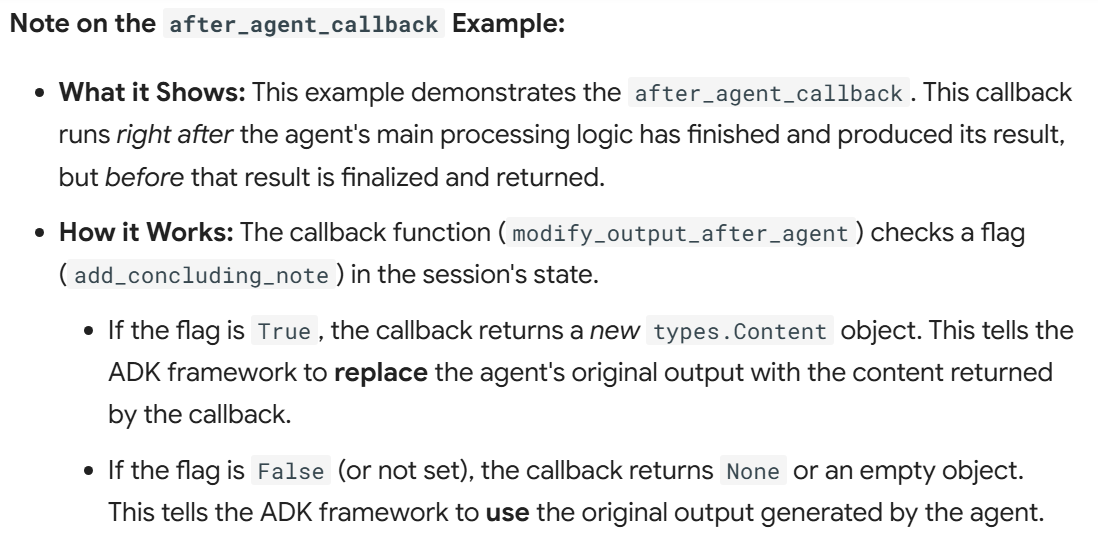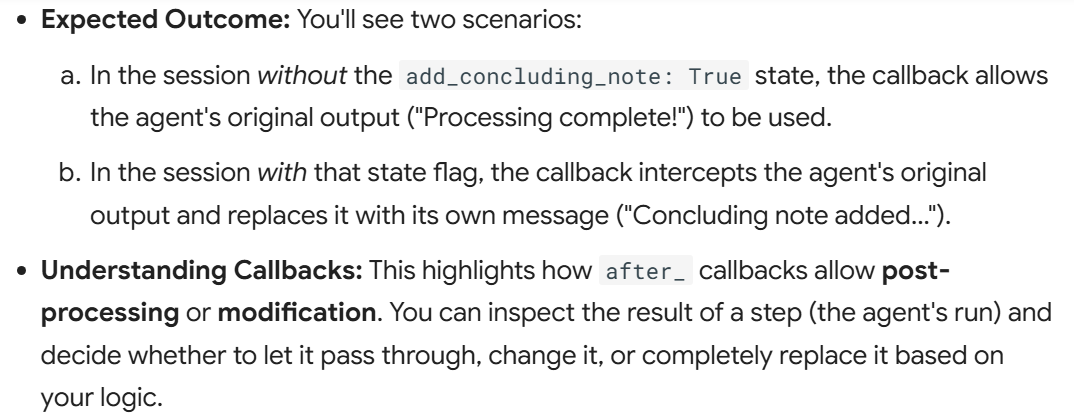

## LLM Interaction Callbacks
These callbacks are specific to `LlmAgent` and provide hooks around the interaction with the Large Language Model.<br><br>

## `Before Model Callback`
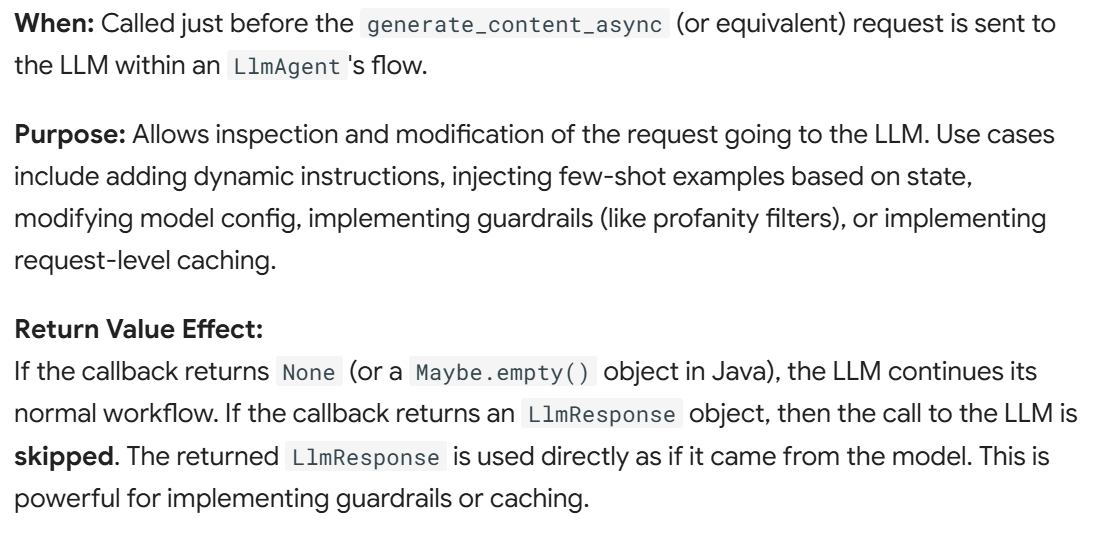

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmResponse, LlmRequest
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService

GEMINI_2_FLASH="gemini-2.0-flash"

# --- Define the Callback Function ---
def simple_before_model_modifier(
    callback_context: CallbackContext, llm_request: LlmRequest
) -> Optional[LlmResponse]:
    """Inspects/modifies the LLM request or skips the call."""
    agent_name = callback_context.agent_name
    print(f"[Callback] Before model call for agent: {agent_name}")

    # Inspect the last user message in the request contents
    last_user_message = ""
    if llm_request.contents and llm_request.contents[-1].role == 'user':
         if llm_request.contents[-1].parts:
            last_user_message = llm_request.contents[-1].parts[0].text
    print(f"[Callback] Inspecting last user message: '{last_user_message}'")

    # --- Modification Example ---
    # Add a prefix to the system instruction
    original_instruction = llm_request.config.system_instruction or types.Content(role="system", parts=[])
    prefix = "[Modified by Callback] "
    # Ensure system_instruction is Content and parts list exists
    if not isinstance(original_instruction, types.Content):
         # Handle case where it might be a string (though config expects Content)
         original_instruction = types.Content(role="system", parts=[types.Part(text=str(original_instruction))])
    if not original_instruction.parts:
        original_instruction.parts.append(types.Part(text="")) # Add an empty part if none exist

    # Modify the text of the first part
    modified_text = prefix + (original_instruction.parts[0].text or "")
    original_instruction.parts[0].text = modified_text
    llm_request.config.system_instruction = original_instruction
    print(f"[Callback] Modified system instruction to: '{modified_text}'")

    # --- Skip Example ---
    # Check if the last user message contains "BLOCK"
    if "BLOCK" in last_user_message.upper():
        print("[Callback] 'BLOCK' keyword found. Skipping LLM call.")
        # Return an LlmResponse to skip the actual LLM call
        return LlmResponse(
            content=types.Content(
                role="model",
                parts=[types.Part(text="LLM call was blocked by before_model_callback.")],
            )
        )
    else:
        print("[Callback] Proceeding with LLM call.")
        # Return None to allow the (modified) request to go to the LLM
        return None


# Create LlmAgent and Assign Callback
my_llm_agent = LlmAgent(
        name="ModelCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are a helpful assistant.", # Base instruction
        description="An LLM agent demonstrating before_model_callback",
        before_model_callback=simple_before_model_modifier # Assign the function here
)

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner


# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("write a joke on BLOCK")
```

## `After Model Callback`
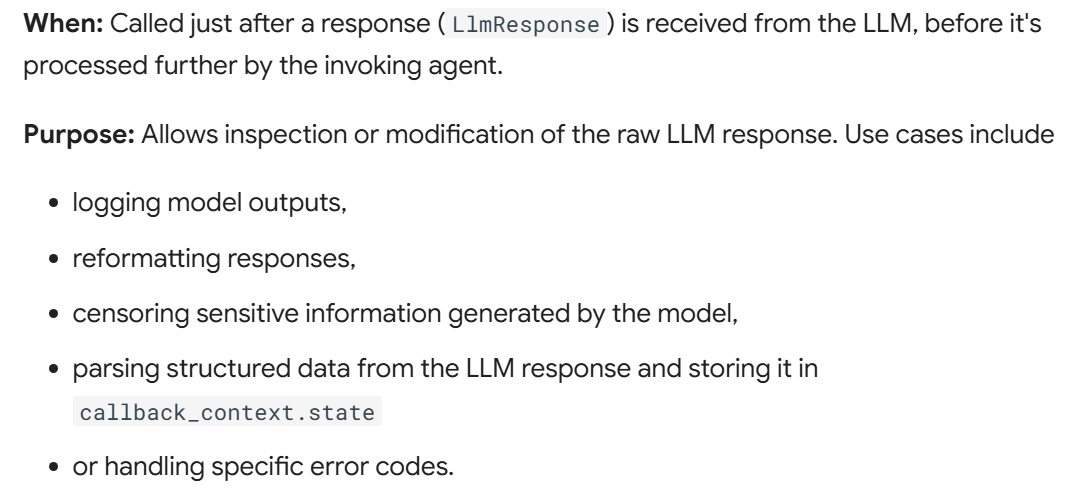

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService
from google.adk.models import LlmResponse

GEMINI_2_FLASH="gemini-2.0-flash"

# --- Define the Callback Function ---
def simple_after_model_modifier(
    callback_context: CallbackContext, llm_response: LlmResponse
) -> Optional[LlmResponse]:
    """Inspects/modifies the LLM response after it's received."""
    agent_name = callback_context.agent_name
    print(f"[Callback] After model call for agent: {agent_name}")

    # --- Inspection ---
    original_text = ""
    if llm_response.content and llm_response.content.parts:
        # Assuming simple text response for this example
        if llm_response.content.parts[0].text:
            original_text = llm_response.content.parts[0].text
            print(f"[Callback] Inspected original response text: '{original_text[:100]}...'") # Log snippet
        elif llm_response.content.parts[0].function_call:
             print(f"[Callback] Inspected response: Contains function call '{llm_response.content.parts[0].function_call.name}'. No text modification.")
             return None # Don't modify tool calls in this example
        else:
             print("[Callback] Inspected response: No text content found.")
             return None
    elif llm_response.error_message:
        print(f"[Callback] Inspected response: Contains error '{llm_response.error_message}'. No modification.")
        return None
    else:
        print("[Callback] Inspected response: Empty LlmResponse.")
        return None # Nothing to modify

    # --- Modification Example ---
    # Replace "joke" with "funny story" (case-insensitive)
    search_term = "joke"
    replace_term = "funny story"
    if search_term in original_text.lower():
        print(f"[Callback] Found '{search_term}'. Modifying response.")
        modified_text = original_text.replace(search_term, replace_term)
        modified_text = modified_text.replace(search_term.capitalize(), replace_term.capitalize()) # Handle capitalization

        # Create a NEW LlmResponse with the modified content
        # Deep copy parts to avoid modifying original if other callbacks exist
        modified_parts = [copy.deepcopy(part) for part in llm_response.content.parts]
        modified_parts[0].text = modified_text # Update the text in the copied part

        new_response = LlmResponse(
             content=types.Content(role="model", parts=modified_parts),
             # Copy other relevant fields if necessary, e.g., grounding_metadata
             grounding_metadata=llm_response.grounding_metadata
             )
        print(f"[Callback] Returning modified response.")
        return new_response # Return the modified response
    else:
        print(f"[Callback] '{search_term}' not found. Passing original response through.")
        # Return None to use the original llm_response
        return None


# Create LlmAgent and Assign Callback
my_llm_agent = LlmAgent(
        name="AfterModelCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are a helpful assistant.",
        description="An LLM agent demonstrating after_model_callback",
        after_model_callback=simple_after_model_modifier # Assign the function here
)

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner

# Agent Interaction
async def call_agent_async(query):
  session, runner = await setup_session_and_runner()

  content = types.Content(role='user', parts=[types.Part(text=query)])
  events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

  async for event in events:
      if event.is_final_response():
          final_response = event.content.parts[0].text
          print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("""write multiple time the word "joke" """)
```

## Tool Execution Callbacks
These callbacks are also specific to `LlmAgent` and trigger around the execution of tools (including `FunctionTool`, `AgentTool`, etc.) that the LLM might request. <br><br>

## `Before Tool Callback`
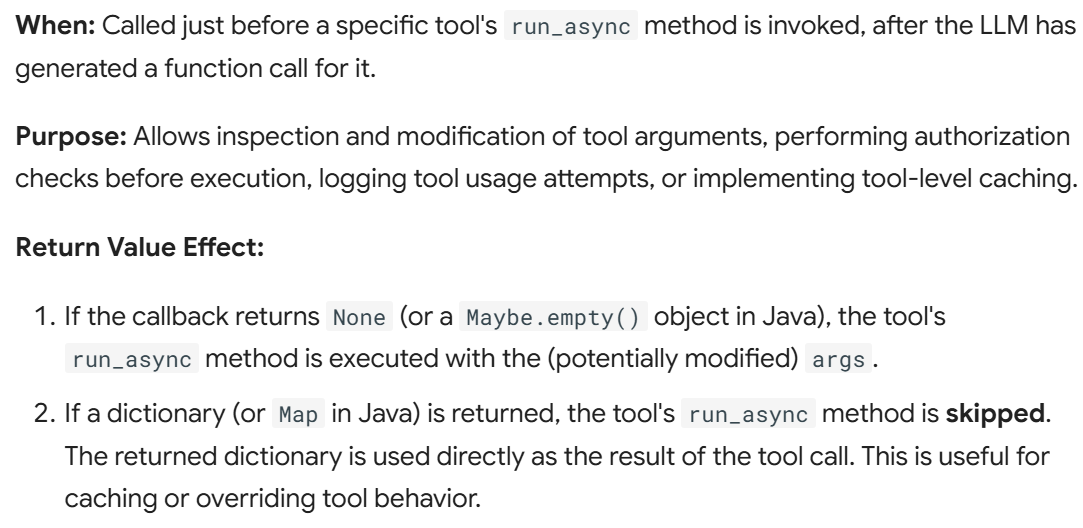

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService
from google.adk.tools import FunctionTool
from google.adk.tools.tool_context import ToolContext
from google.adk.tools.base_tool import BaseTool
from typing import Dict, Any


GEMINI_2_FLASH="gemini-2.0-flash"

def get_capital_city(country: str) -> str:
    """Retrieves the capital city of a given country."""
    print(f"--- Tool 'get_capital_city' executing with country: {country} ---")
    country_capitals = {
        "united states": "Washington, D.C.",
        "canada": "Ottawa",
        "france": "Paris",
        "germany": "Berlin",
    }
    return country_capitals.get(country.lower(), f"Capital not found for {country}")

capital_tool = FunctionTool(func=get_capital_city)

def simple_before_tool_modifier(
    tool: BaseTool, args: Dict[str, Any], tool_context: ToolContext
) -> Optional[Dict]:
    """Inspects/modifies tool args or skips the tool call."""
    agent_name = tool_context.agent_name
    tool_name = tool.name
    print(f"[Callback] Before tool call for tool '{tool_name}' in agent '{agent_name}'")
    print(f"[Callback] Original args: {args}")

    if tool_name == 'get_capital_city' and args.get('country', '').lower() == 'canada':
        print("[Callback] Detected 'Canada'. Modifying args to 'France'.")
        args['country'] = 'France'
        print(f"[Callback] Modified args: {args}")
        return None

    # If the tool is 'get_capital_city' and country is 'BLOCK'
    if tool_name == 'get_capital_city' and args.get('country', '').upper() == 'BLOCK':
        print("[Callback] Detected 'BLOCK'. Skipping tool execution.")
        return {"result": "Tool execution was blocked by before_tool_callback."}

    print("[Callback] Proceeding with original or previously modified args.")
    return None

my_llm_agent = LlmAgent(
        name="ToolCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are an agent that can find capital cities. Use the get_capital_city tool.",
        description="An LLM agent demonstrating before_tool_callback",
        tools=[capital_tool],
        before_tool_callback=simple_before_tool_modifier
)

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner

# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("Canada")
```

## `After Tool Callback`
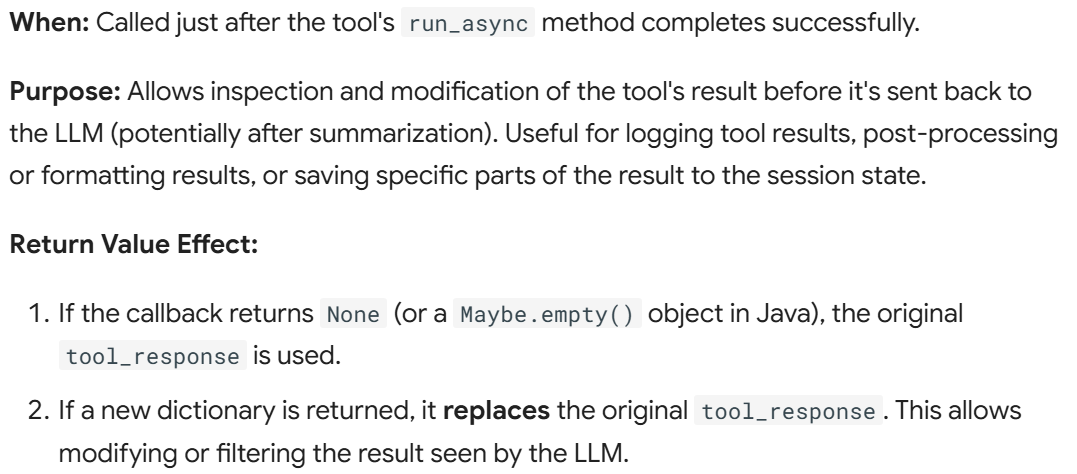

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService
from google.adk.tools import FunctionTool
from google.adk.tools.tool_context import ToolContext
from google.adk.tools.base_tool import BaseTool
from typing import Dict, Any
from copy import deepcopy

GEMINI_2_FLASH="gemini-2.0-flash"

# --- Define a Simple Tool Function (Same as before) ---
def get_capital_city(country: str) -> str:
    """Retrieves the capital city of a given country."""
    print(f"--- Tool 'get_capital_city' executing with country: {country} ---")
    country_capitals = {
        "united states": "Washington, D.C.",
        "canada": "Ottawa",
        "france": "Paris",
        "germany": "Berlin",
    }
    return {"result": country_capitals.get(country.lower(), f"Capital not found for {country}")}

# --- Wrap the function into a Tool ---
capital_tool = FunctionTool(func=get_capital_city)

# --- Define the Callback Function ---
def simple_after_tool_modifier(
    tool: BaseTool, args: Dict[str, Any], tool_context: ToolContext, tool_response: Dict
) -> Optional[Dict]:
    """Inspects/modifies the tool result after execution."""
    agent_name = tool_context.agent_name
    tool_name = tool.name
    print(f"[Callback] After tool call for tool '{tool_name}' in agent '{agent_name}'")
    print(f"[Callback] Args used: {args}")
    print(f"[Callback] Original tool_response: {tool_response}")

    # Default structure for function tool results is {"result": <return_value>}
    original_result_value = tool_response.get("result", "")
    # original_result_value = tool_response

    # --- Modification Example ---
    # If the tool was 'get_capital_city' and result is 'Washington, D.C.'
    if tool_name == 'get_capital_city' and original_result_value == "Washington, D.C.":
        print("[Callback] Detected 'Washington, D.C.'. Modifying tool response.")

        # IMPORTANT: Create a new dictionary or modify a copy
        modified_response = deepcopy(tool_response)
        modified_response["result"] = f"{original_result_value} (Note: This is the capital of the USA)."
        modified_response["note_added_by_callback"] = True # Add extra info if needed

        print(f"[Callback] Modified tool_response: {modified_response}")
        return modified_response # Return the modified dictionary

    print("[Callback] Passing original tool response through.")
    # Return None to use the original tool_response
    return None


# Create LlmAgent and Assign Callback
my_llm_agent = LlmAgent(
        name="AfterToolCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are an agent that finds capital cities using the get_capital_city tool. Report the result clearly.",
        description="An LLM agent demonstrating after_tool_callback",
        tools=[capital_tool], # Add the tool
        after_tool_callback=simple_after_tool_modifier # Assign the callback
    )

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner


# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("united states")
```

----

# Callback Patterns
## Design Patterns and Best Practices for Callbacks
Callbacks offer powerful hooks into the agent lifecycle. Here are common design patterns illustrating how to leverage them effectively in ADK, followed by best practices for implementation.<br><br>
## Design Patterns
These patterns demonstrate typical ways to enhance or control agent behavior using callbacks:<br>
### 1. Guardrails & Policy Enforcement
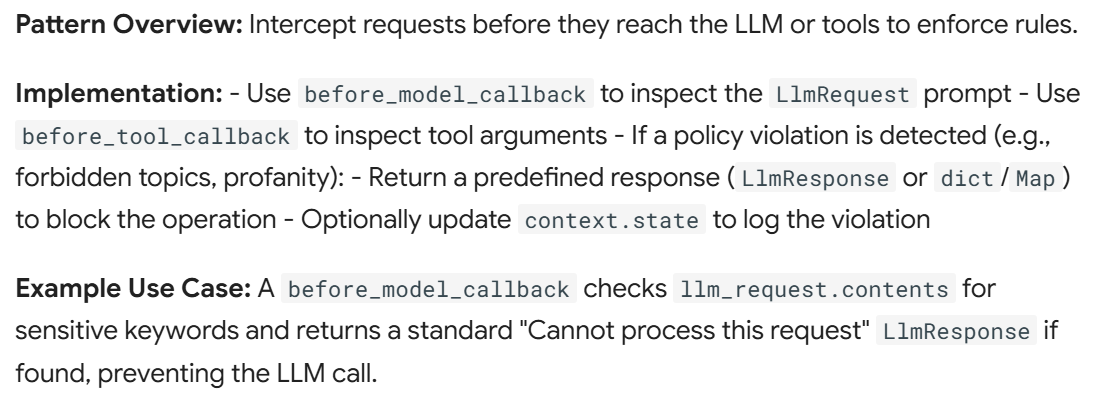

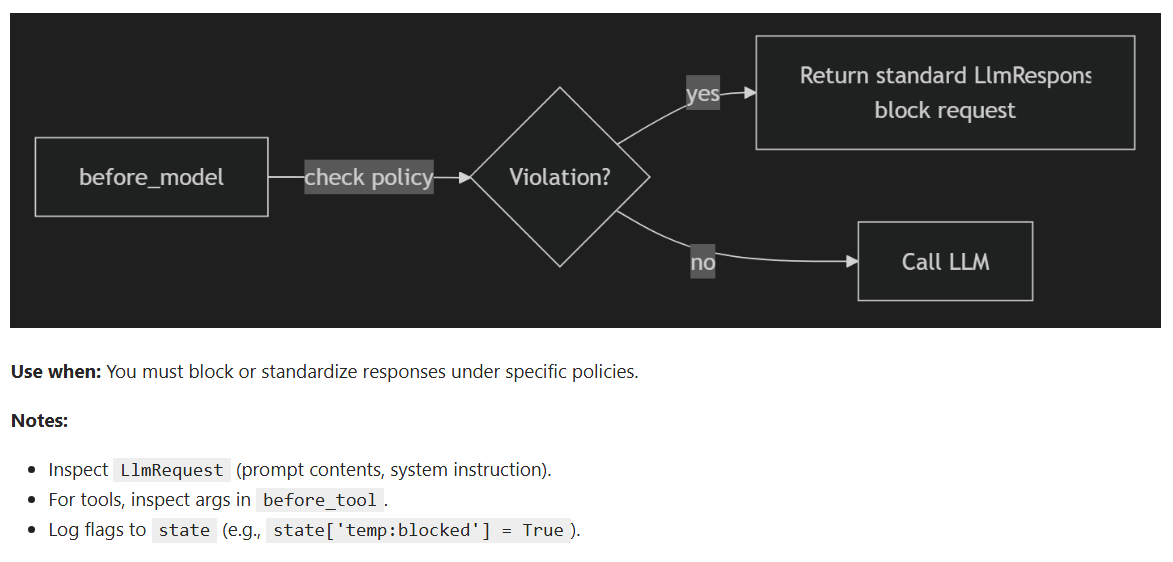

### 2. Dynamic State Management
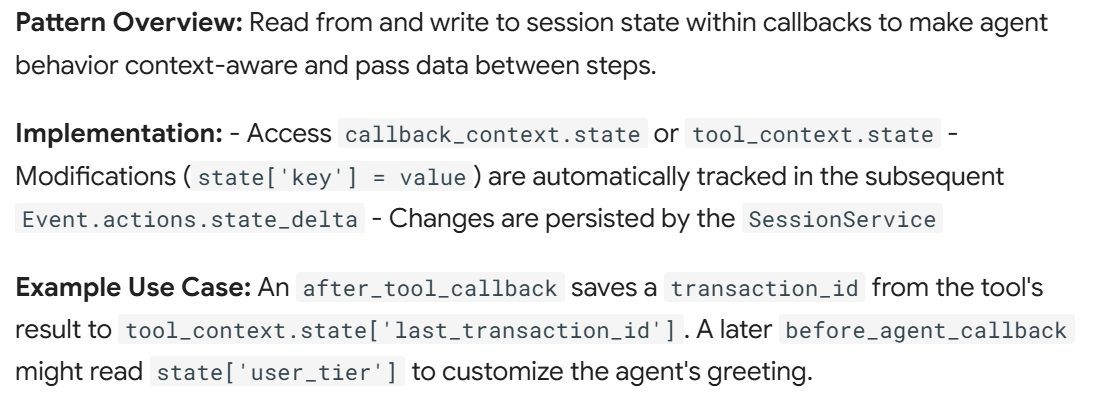

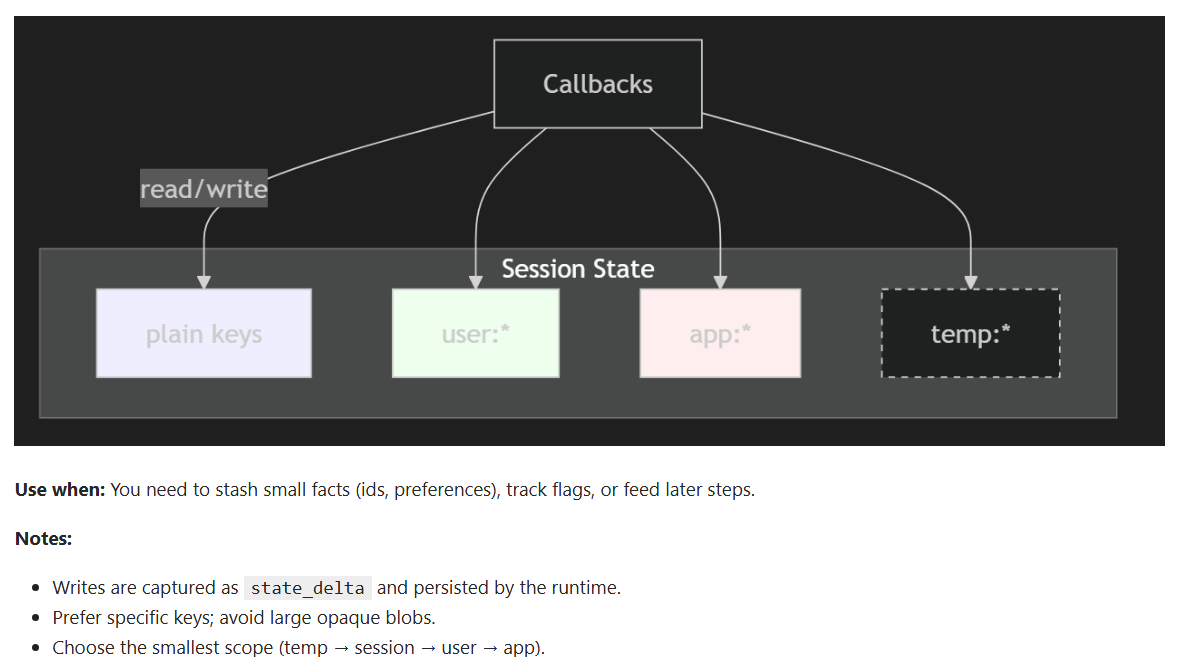

## 3. Logging and Monitoring
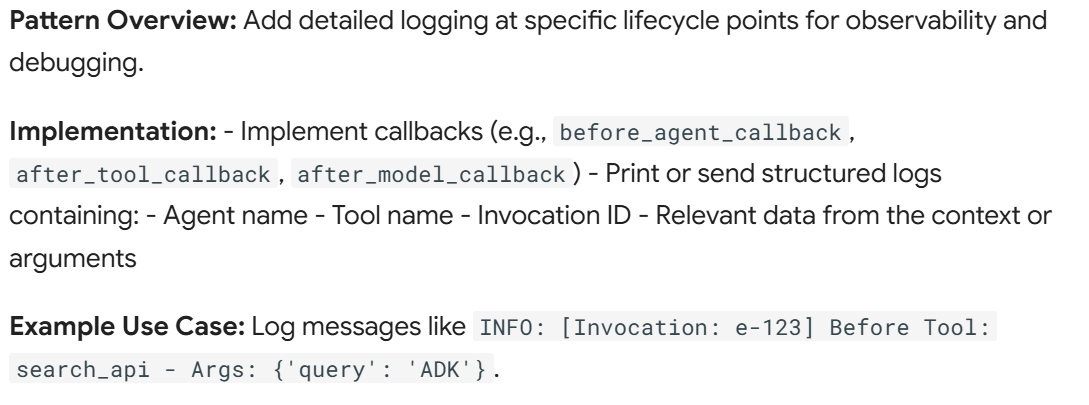

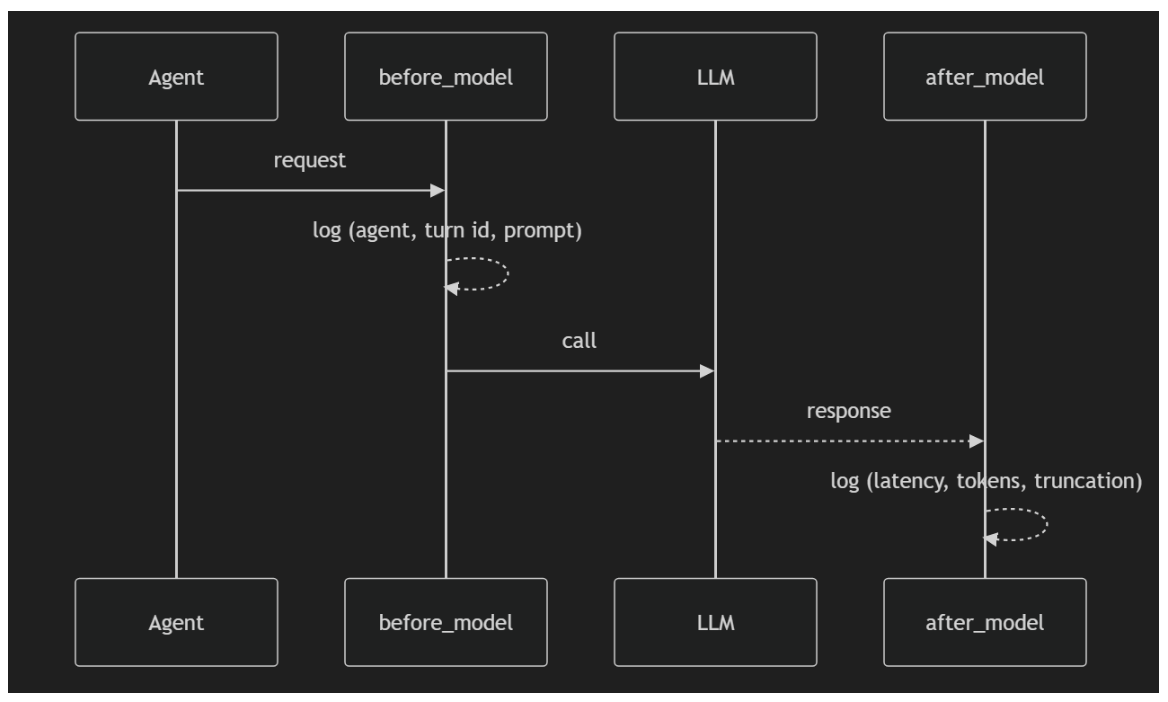

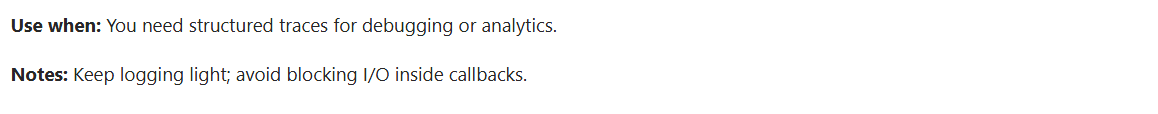

## 4. Caching
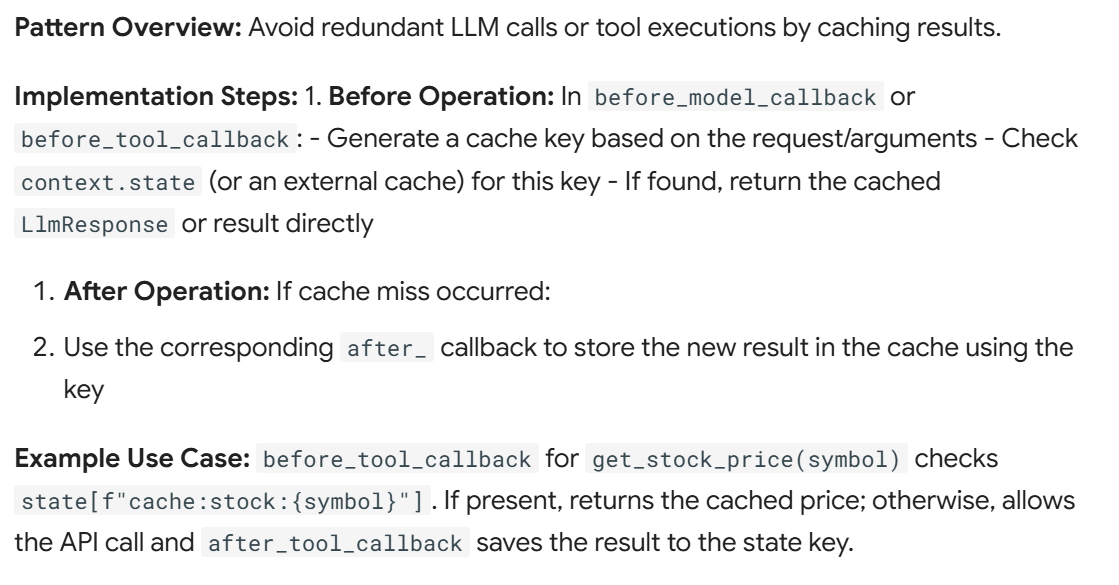 

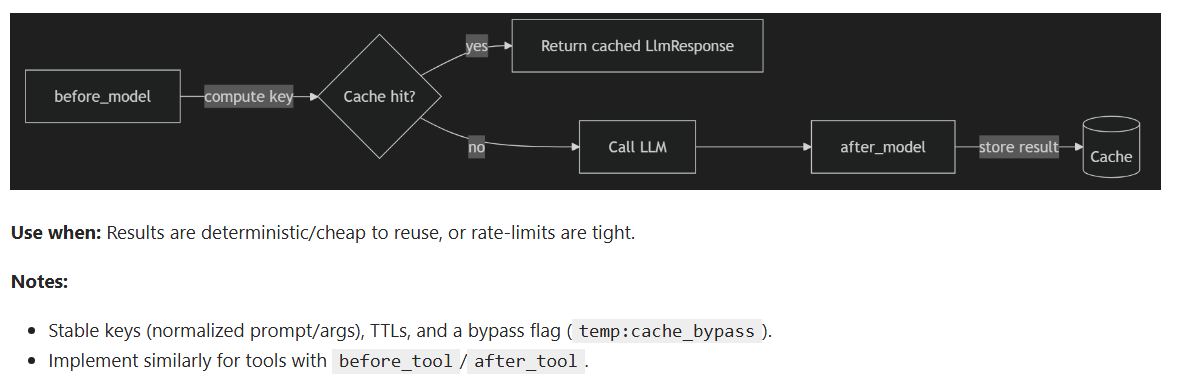

## 5. Request/Response Modification
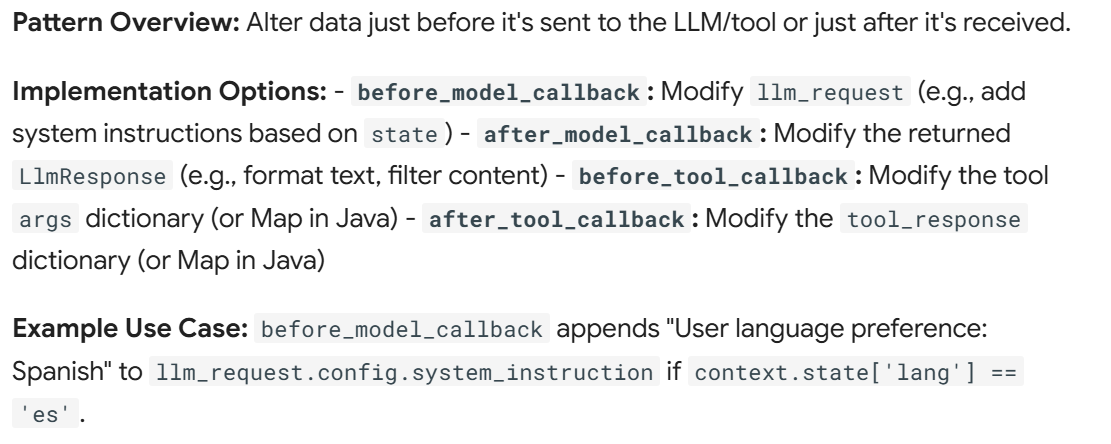

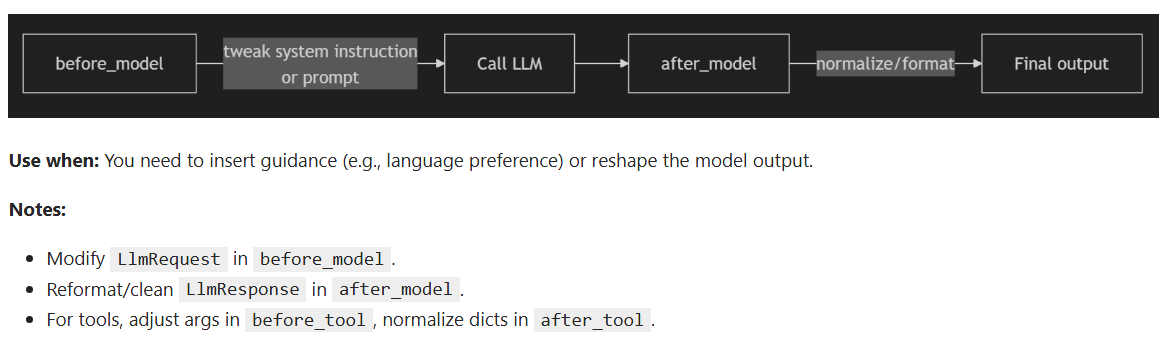

## 6. Conditional Skipping of Steps
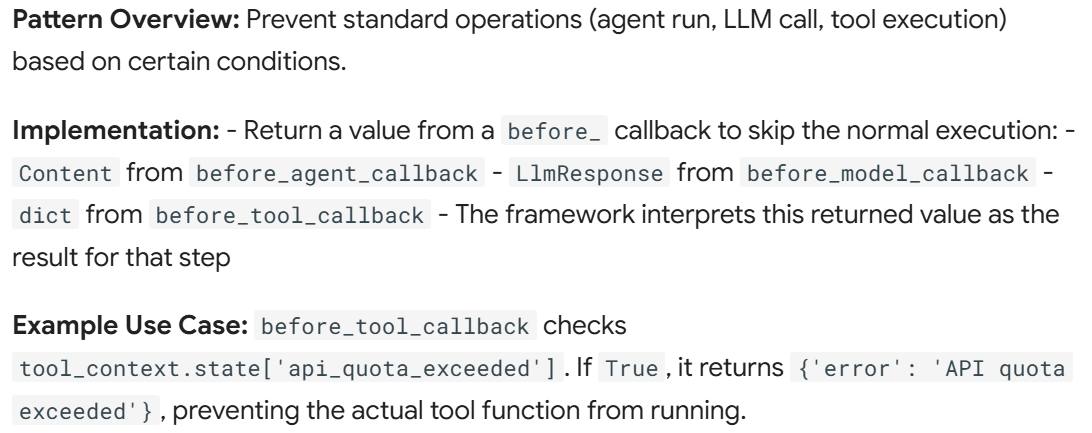

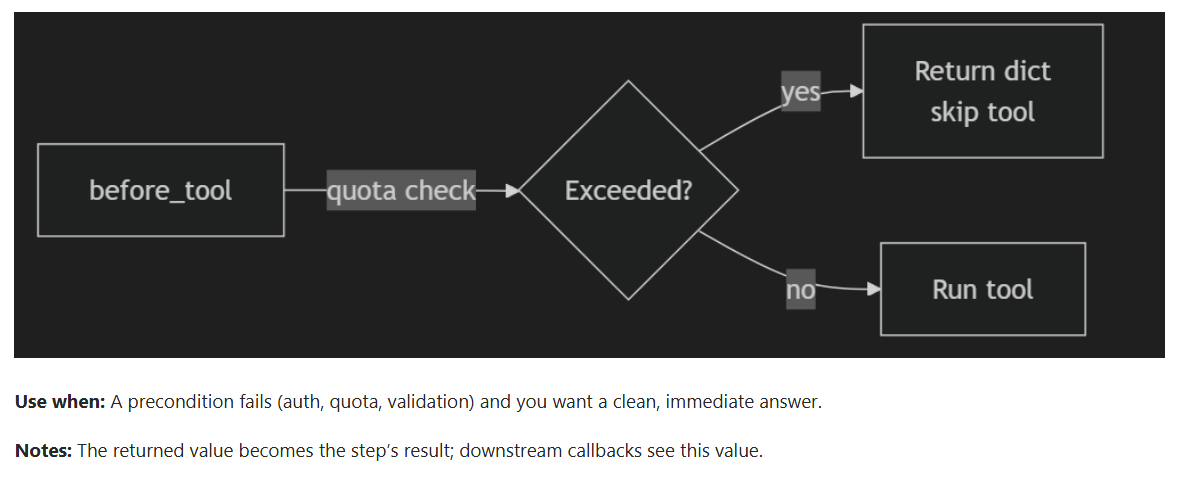

## 7. Tool-Specific Actions (Authentication & Summarization Control)
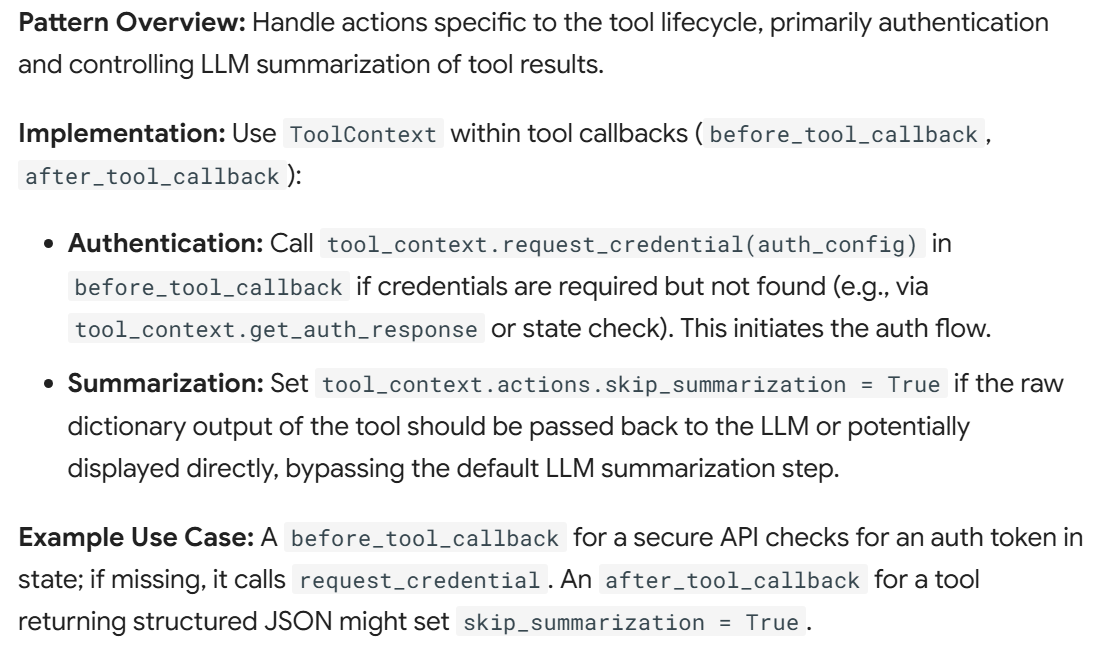 

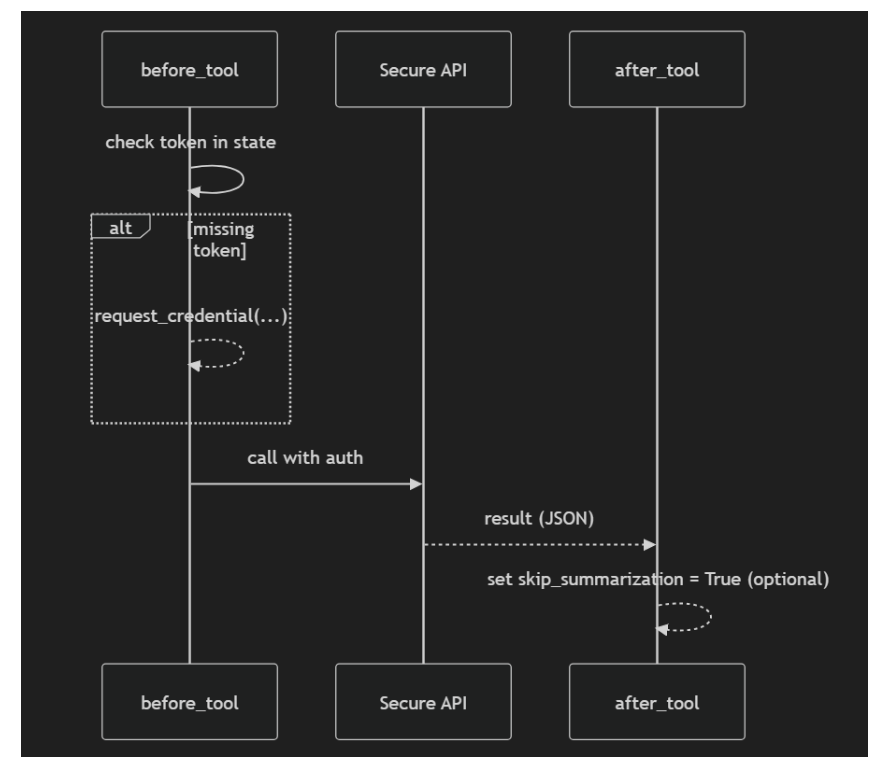

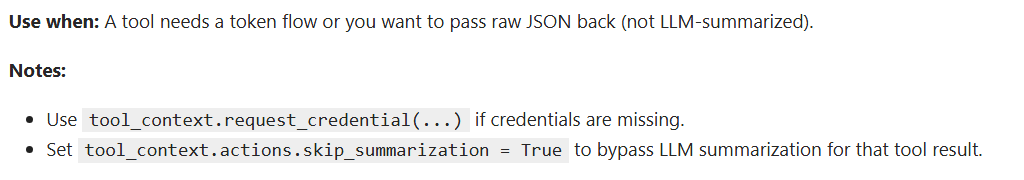

## 8. Artifact Handling
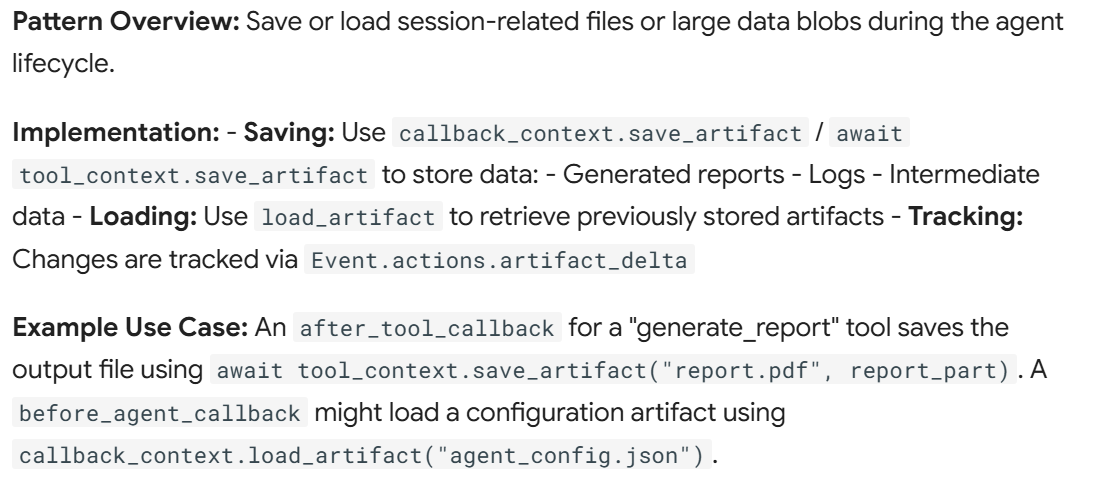 

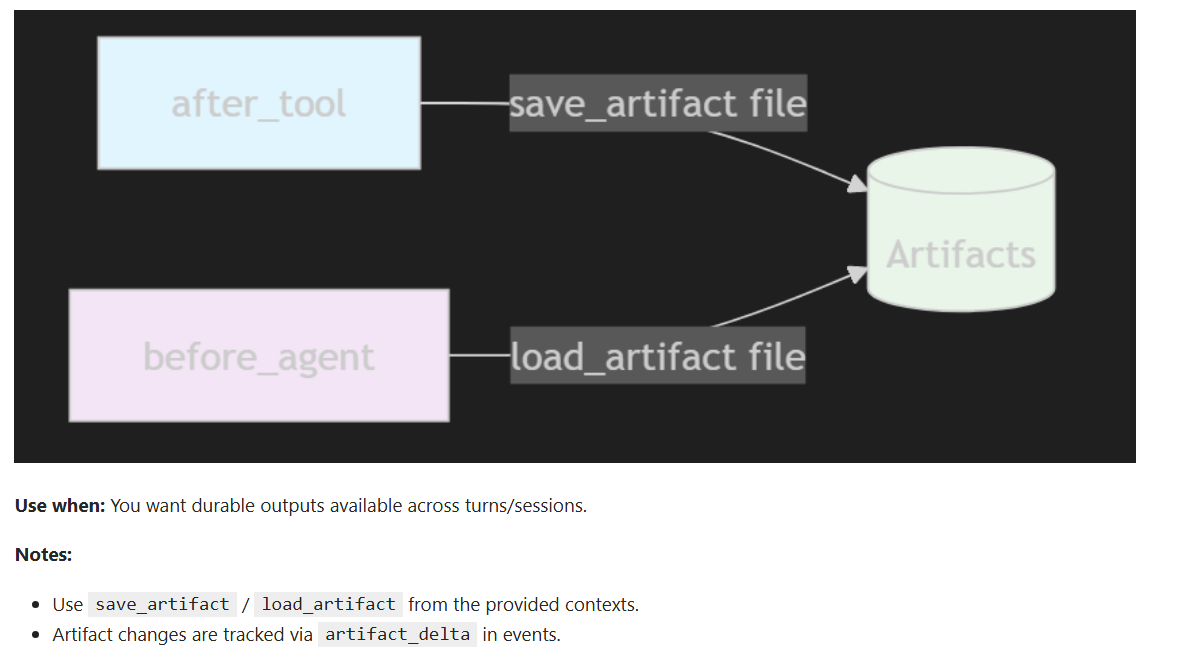

## Best Practices for Callbacks
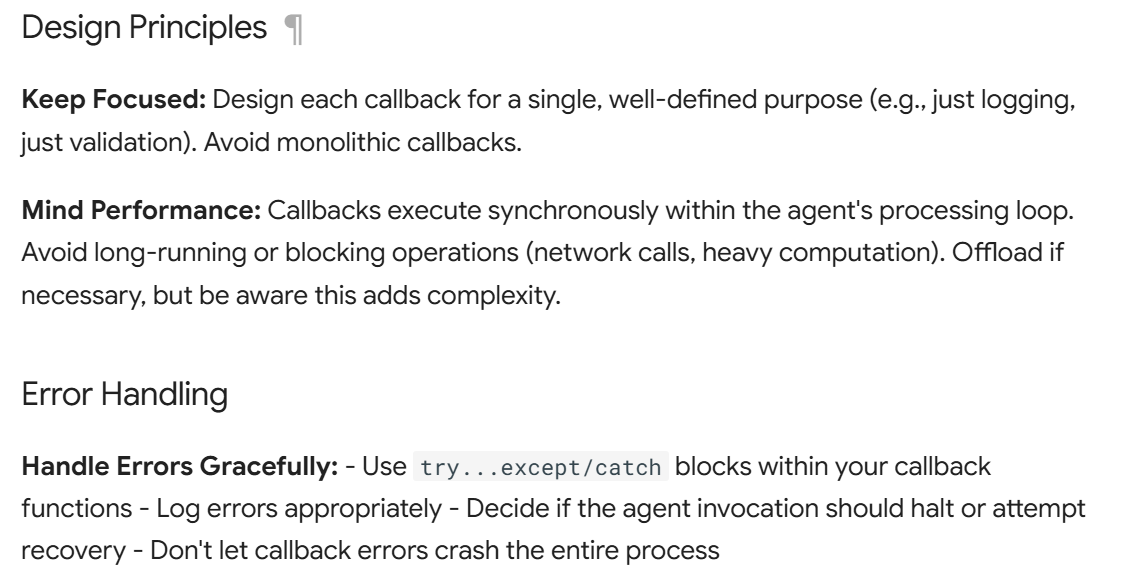
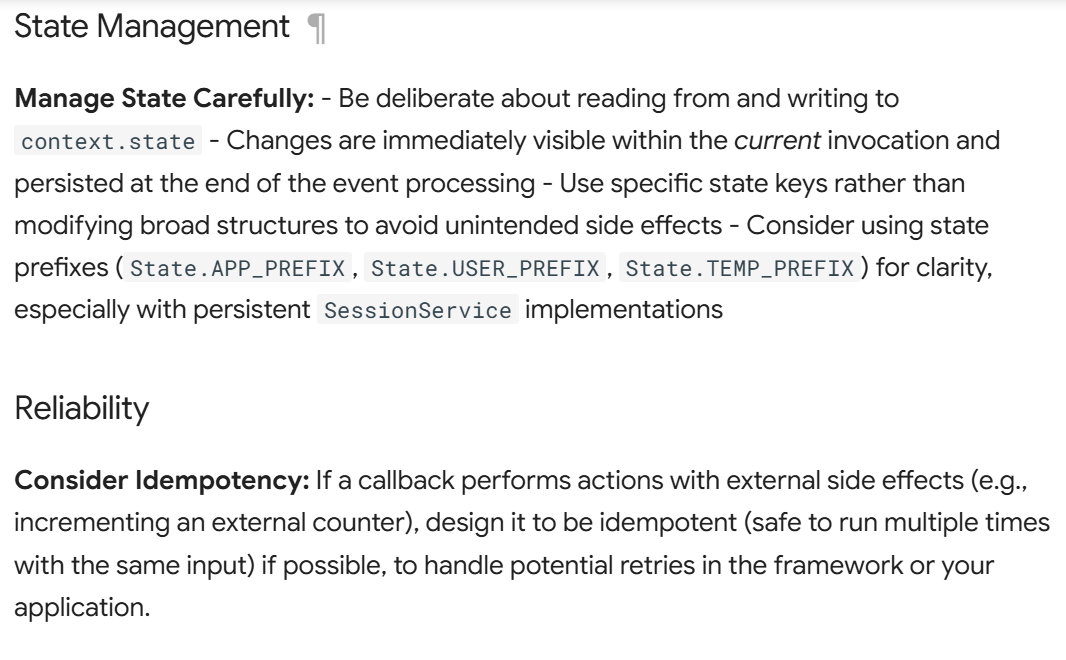
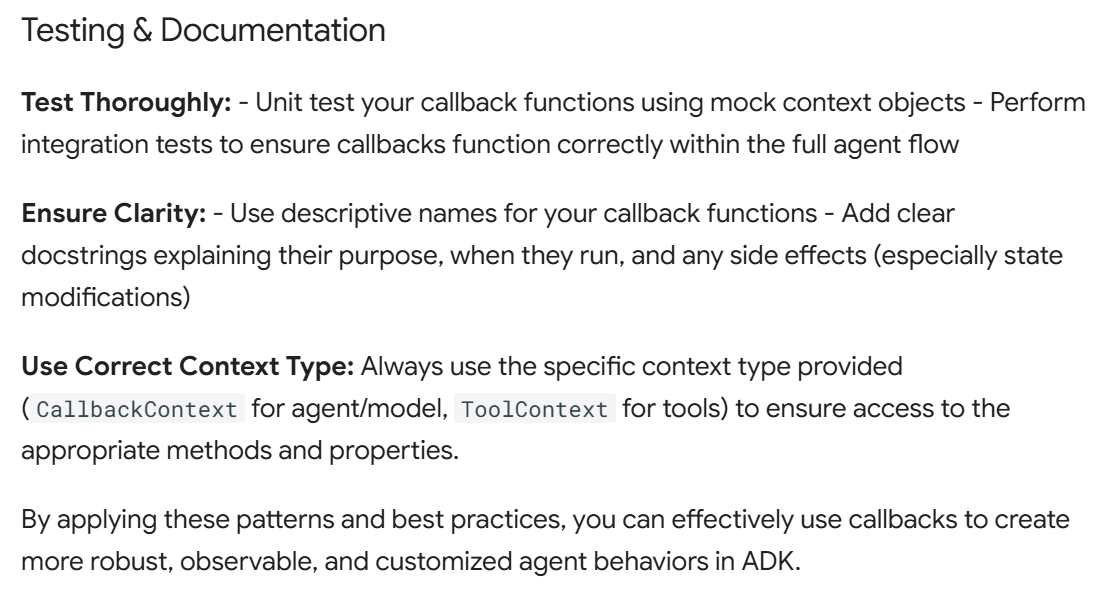
---



---

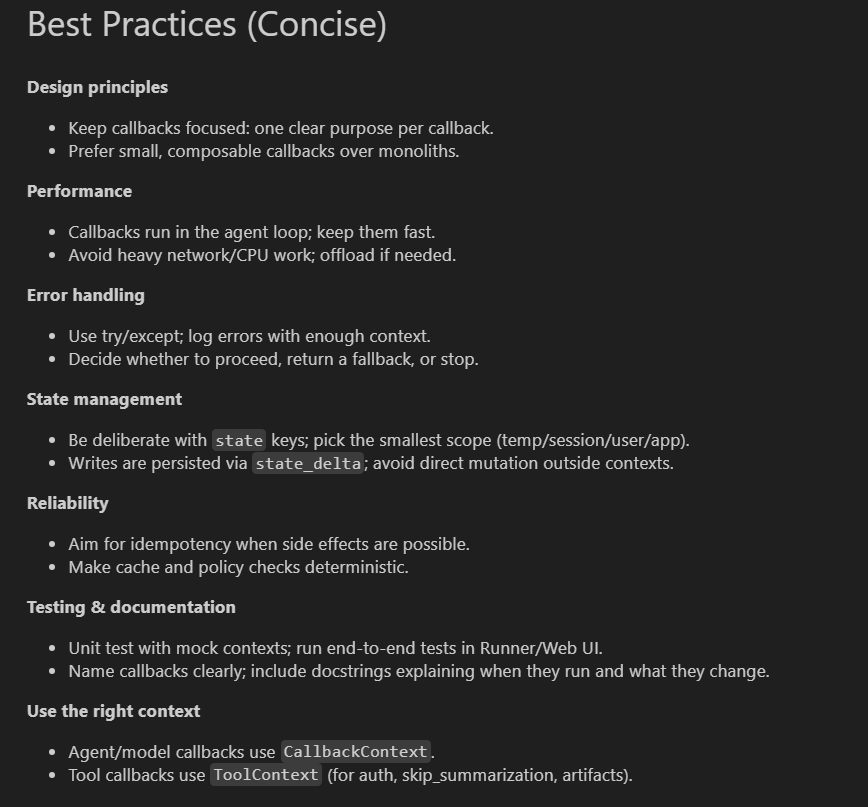

---